In [20]:
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, PathSolver,AntennaPattern, register_antenna_pattern, RadioMapSolver
import mitsuba as mi
import drjit as dr

Directivity [dB]: 9.83
Gain [dB]: 8.0
Efficiency [%]: 65.7


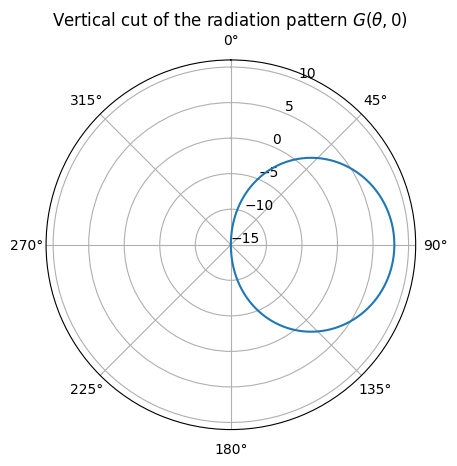

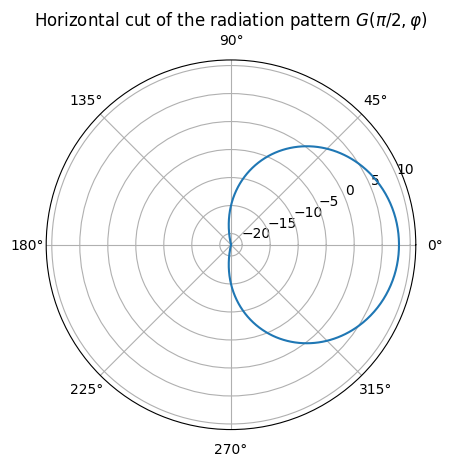

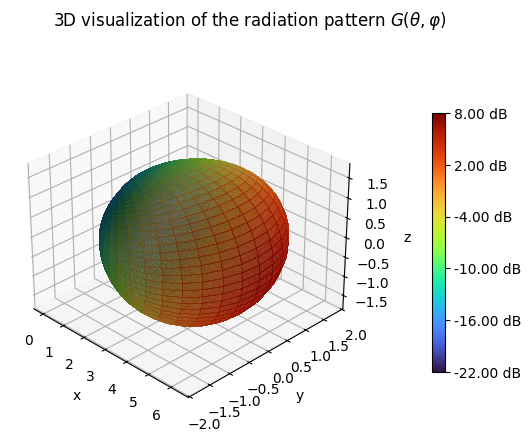

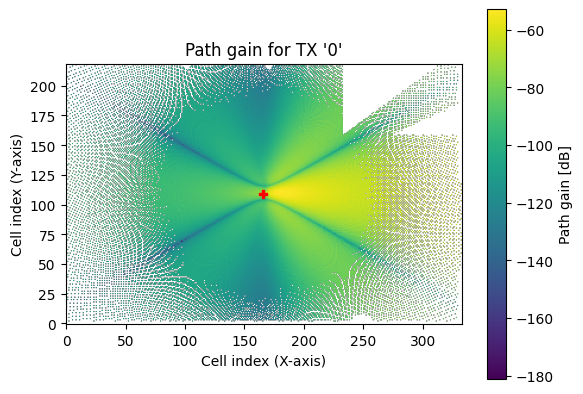

In [26]:
scene = load_scene("room/room.xml",merge_shapes=False)
scene.frequency = 40e9 #Hz
scene.synthetic_array = True

#Configure antenna array
scene.tx_array = PlanarArray(
   num_rows=1,
   num_cols=4,
   vertical_spacing=0.5,
   horizontal_spacing=0.5,
   pattern="tr38901",
   polarization="V")
   #sharpness=100.0 )

scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="dipole",
    polarization="V")

# Transmitter
tx = Transmitter(name="tx",
                 position=mi.Point3f(0, 0, 1),
                 orientation=mi.Point3f(0, 0, 0))
scene.add(tx)

# Receiver
rx = Receiver(name="rx",
                 position=[6,4,1],
                 orientation=(0.0, 0.0, 0.0))
scene.add(rx)

# Antenna direction
tx.look_at([5,0,1])

# pSolver = PathSolver()
# paths = pSolver(scene, max_depth=3, synthetic_array=False)
# scene.preview(paths=paths)

# Antenna
scene.tx_array.antenna_pattern.compute_gain()
scene.tx_array.antenna_pattern.show()

# Radio Map
rmSolver = RadioMapSolver()
rm = rmSolver(scene, max_depth=0, cell_size=[0.05, 0.05])
scene.preview(radio_map=rm, clip_at=15., rm_vmin=-100.)
rmPlot = rm.show(tx=0)